# RQ2-Analyse — RAG-Konfigurations-Vergleich

Wertet die Konfigurations-Läufe aus (Versionsnamen mit `__`). Vergleicht die
**Retrieval-Qualität** je Konfiguration anhand von `TurnContextualRelevancy` und
`TurnFaithfulness` sowie der **Retrieval-Abdeckung** (Anteil Antworten mit Kontext,
aus den Konversations-JSONs).

> Bei fehlenden Paketen: `pip install pandas matplotlib`


In [10]:
import glob, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Pfade (ggf. anpassen) ----
CSV_GLOB  = "../persistence/csv/eval_rohdaten_system_prompt__*.csv"          # nur RQ2 (mit __)
CONV_GLOB = "../persistence/konversationen/konversationen_*__*.json"
RAG_METRIKEN = ["Turn Contextual Relevancy", "Turn Faithfulness"]
NEEDED = ["prompt_version", "conversation_id", "metric", "score"]
print(CSV_GLOB, "eval_rohdaten_system_prompt__beide_hybrid")

../persistence/csv/eval_rohdaten_system_prompt__*.csv eval_rohdaten_system_prompt__beide_hybrid


## 1. RQ2-Rohdaten laden

In [11]:
files = glob.glob(CSV_GLOB)
if not files:
    raise FileNotFoundError(f"Keine RQ2-CSVs unter {CSV_GLOB} gefunden. "
                            "Wurde die Evaluation (RUN_EVALUATION=true) fuer rq2 gelaufen?")
print("Gefundene RQ2-CSVs:", files)
df = pd.concat(
    [pd.read_csv(f, encoding="utf-8-sig", engine="python", usecols=lambda c: c in NEEDED) for f in files],
    ignore_index=True,
)
df["score"]  = pd.to_numeric(df["score"], errors="coerce")
df["metrik"] = df["metric"].astype(str).str.strip()
df["config"] = df["prompt_version"].astype(str).str.split("__").str[1]
print("Konfigurationen:", sorted(df["config"].unique()))
df.head()

Gefundene RQ2-CSVs: ['../persistence/csv\\eval_rohdaten_system_prompt__beide_dense.csv', '../persistence/csv\\eval_rohdaten_system_prompt__beide_hybrid.csv', '../persistence/csv\\eval_rohdaten_system_prompt__beide_hybrid_rerank.csv', '../persistence/csv\\eval_rohdaten_system_prompt__beide_sparse.csv', '../persistence/csv\\eval_rohdaten_system_prompt__labor_dense.csv', '../persistence/csv\\eval_rohdaten_system_prompt__labor_hybrid_rerank.csv', '../persistence/csv\\eval_rohdaten_system_prompt__llm_only.csv', '../persistence/csv\\eval_rohdaten_system_prompt__vorlesung_dense.csv', '../persistence/csv\\eval_rohdaten_system_prompt__vorlesung_hybrid_rerank.csv']
Konfigurationen: ['beide_dense', 'beide_hybrid', 'beide_hybrid_rerank', 'beide_sparse', 'labor_dense', 'labor_hybrid_rerank', 'llm_only', 'vorlesung_dense', 'vorlesung_hybrid_rerank']


,prompt_version,conversation_id,metric,score,metrik,config
0,system_prompt__beide_dense,28f98d1cb3,[GEval] Lösung nicht verraten [Conversational ...,1.0,[GEval] Lösung nicht verraten [Conversational ...,beide_dense
1,system_prompt__beide_dense,28f98d1cb3,[GEval] Sokratische Rückfragen [Conversational...,1.0,[GEval] Sokratische Rückfragen [Conversational...,beide_dense
2,system_prompt__beide_dense,28f98d1cb3,[GEval] Schrittweises Vorgehen [Conversational...,1.0,[GEval] Schrittweises Vorgehen [Conversational...,beide_dense
3,system_prompt__beide_dense,28f98d1cb3,[GEval] Niveau-Anpassung [Conversational GEval],1.0,[GEval] Niveau-Anpassung [Conversational GEval],beide_dense
4,system_prompt__beide_dense,28f98d1cb3,[GEval] Fachliche Korrektheit [Conversational ...,1.0,[GEval] Fachliche Korrektheit [Conversational ...,beide_dense


## 2. RAG-Metriken je Konfiguration (Mittelwert, Std, n)

In [15]:
rag = df[df["metrik"].isin(RAG_METRIKEN)].dropna(subset=["score"])
stats = (rag.groupby(["config", "metrik"])["score"]
         .agg(n="count", mean="mean", std="std")
         .round(3))
stats
print(df["metrik"].unique())

<StringArray>
[          '[GEval] Lösung nicht verraten [Conversational GEval]',
          '[GEval] Sokratische Rückfragen [Conversational GEval]',
          '[GEval] Schrittweises Vorgehen [Conversational GEval]',
                '[GEval] Niveau-Anpassung [Conversational GEval]',
           '[GEval] Fachliche Korrektheit [Conversational GEval]',
 '[GEval] Verständnisförderung / Transfer [Conversational GEval]',
      '[GEval] Respektvolle Kommunikation [Conversational GEval]',
                                                 'Role Adherence']
Length: 8, dtype: str


## 3. Vergleich der Konfigurationen (Balken je RAG-Metrik)

TypeError: no numeric data to plot

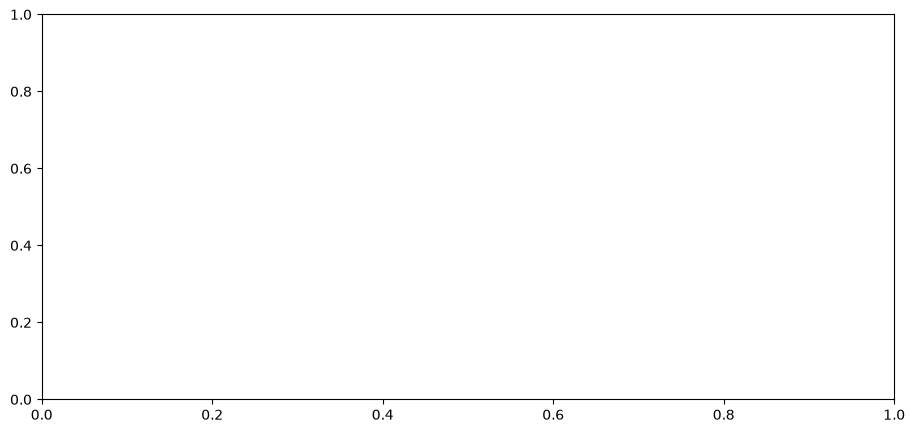

In [13]:
piv = rag.pivot_table(index="config", columns="metrik", values="score", aggfunc="mean").round(3)
ax = piv.plot(kind="bar", figsize=(11, 5))
ax.axhline(0.7, color="#d85a30", ls="--")
ax.set_ylim(0, 1); ax.set_ylabel("Ø Score"); ax.set_title("RAG-Metriken je Konfiguration (RQ2)")
ax.legend(loc="lower right"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
piv

## 4. Retrieval-Abdeckung je Konfiguration

Aus den Konversations-JSONs: Anteil der Assistant-Antworten mit tatsächlich abgerufenem
`retrieval_context`. Der wichtigste label-freie Indikator, ob eine Konfiguration
überhaupt Kontext liefert.

In [ ]:
rows = []
for f in glob.glob(CONV_GLOB):
    version = os.path.basename(f).replace("konversationen_", "").replace(".json", "")
    config = version.split("__")[1] if "__" in version else version
    d = json.load(open(f, encoding="utf-8"))
    tot = wc = 0
    for c in d:
        for t in c["turns"]:
            if t["role"] == "assistant":
                tot += 1
                if t.get("retrieval_context"):
                    wc += 1
    rows.append({"config": config, "antworten": tot, "mit_kontext": wc,
                 "abdeckung_%": round(wc / tot * 100) if tot else 0})
cov = pd.DataFrame(rows).sort_values("abdeckung_%", ascending=False).reset_index(drop=True)
cov

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(cov["config"], cov["abdeckung_%"], color="#1d9e75")
plt.ylabel("Retrieval-Abdeckung (%)"); plt.title("Anteil Antworten mit Kontext je Konfiguration")
plt.xticks(rotation=30, ha="right"); plt.ylim(0, 100); plt.tight_layout(); plt.show()

## 5. Gesamtranking je Konfiguration

In [ ]:
rang = piv.copy()
rang = rang.merge(cov.set_index("config")[["abdeckung_%"]], left_index=True, right_index=True, how="left")
rang = rang.sort_values(RAG_METRIKEN[0], ascending=False)
rang

## 6. Ergebnisse speichern

In [ ]:
stats.to_csv("rq2_metrik_stats.csv")
rang.to_csv("rq2_konfiguration_ranking.csv")
cov.to_csv("rq2_retrieval_abdeckung.csv", index=False)
print("gespeichert: rq2_metrik_stats.csv, rq2_konfiguration_ranking.csv, rq2_retrieval_abdeckung.csv")